In [24]:
import numpy as np 
import pandas as pd

In [25]:
df = pd.read_csv("IMDB Dataset.csv")

In [26]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [27]:
#Label Encoding
from sklearn.preprocessing import LabelEncoder
labelEnc = LabelEncoder()

df['sentiment'] = labelEnc.fit_transform(df['sentiment'])
df['sentiment'].head()

0    1
1    1
2    1
3    0
4    1
Name: sentiment, dtype: int32

# EDA

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

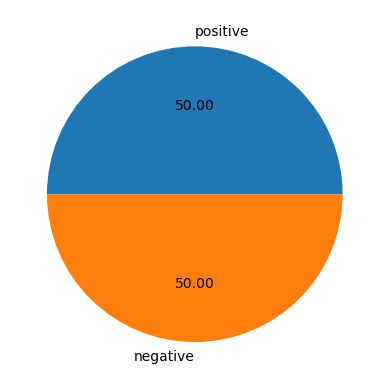

In [30]:
plt.pie(df['sentiment'].value_counts(), labels = ["positive","negative"], autopct="%0.2f")
plt.show()

In [31]:
#Data is Balanced

In [32]:
import nltk

In [33]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\chira\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [34]:
# Number of characters Feature
df['num_characters']= df['review'].apply(len)

In [35]:
# Number of words Feature 
# using nltk library

from nltk.tokenize import word_tokenize
df['num_words'] = df['review'].apply(lambda x:len(word_tokenize(x)))

In [36]:
df['num_words']

0        380
1        201
2        205
3        175
4        283
        ... 
49995    241
49996    138
49997    271
49998    240
49999    150
Name: num_words, Length: 50000, dtype: int64

In [37]:
# Number of sentence Feature

df['num_sentence'] = df['review'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [38]:
df.head()

,review,sentiment,num_characters,num_words,num_sentence
0,One of the other reviewers has mentioned that ...,1,1761,380,10
1,A wonderful little production. <br /><br />The...,1,998,201,7
2,I thought this was a wonderful way to spend ti...,1,926,205,4
3,Basically there's a family where a little boy ...,0,748,175,6
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,1317,283,9


In [39]:
df[['num_characters', 'num_words', 'num_sentence']].describe()

,num_characters,num_words,num_sentence
count,50000.000000,50000.000000,50000.000000
mean,1309.431020,279.483720,10.741440
std,989.728014,207.949849,7.900587
min,32.000000,8.000000,1.000000
25%,699.000000,151.000000,6.000000
50%,970.000000,209.000000,9.000000
75%,1590.250000,340.000000,13.000000
max,13704.000000,2911.000000,282.000000


In [40]:
# Positive
df[df['sentiment']==1][['num_characters', 'num_words', 'num_sentence']].describe()

,num_characters,num_words,num_sentence
count,25000.000000,25000.000000,25000.000000
mean,1324.797680,280.358000,10.456000
std,1031.492627,214.399014,7.910758
min,65.000000,11.000000,1.000000
25%,691.000000,148.000000,6.000000
50%,968.000000,207.000000,9.000000
75%,1614.000000,343.000000,13.000000
max,13704.000000,2911.000000,282.000000


In [41]:
# Negative
df[df['sentiment']==0][['num_characters', 'num_words', 'num_sentence']].describe()

,num_characters,num_words,num_sentence
count,25000.000000,25000.000000,25000.000000
mean,1294.064360,278.609440,11.026880
std,945.892669,201.294667,7.880229
min,32.000000,8.000000,1.000000
25%,706.000000,153.000000,6.000000
50%,973.000000,211.000000,9.000000
75%,1567.250000,338.000000,13.000000
max,8969.000000,1936.000000,118.000000


<Axes: xlabel='num_characters', ylabel='Count'>

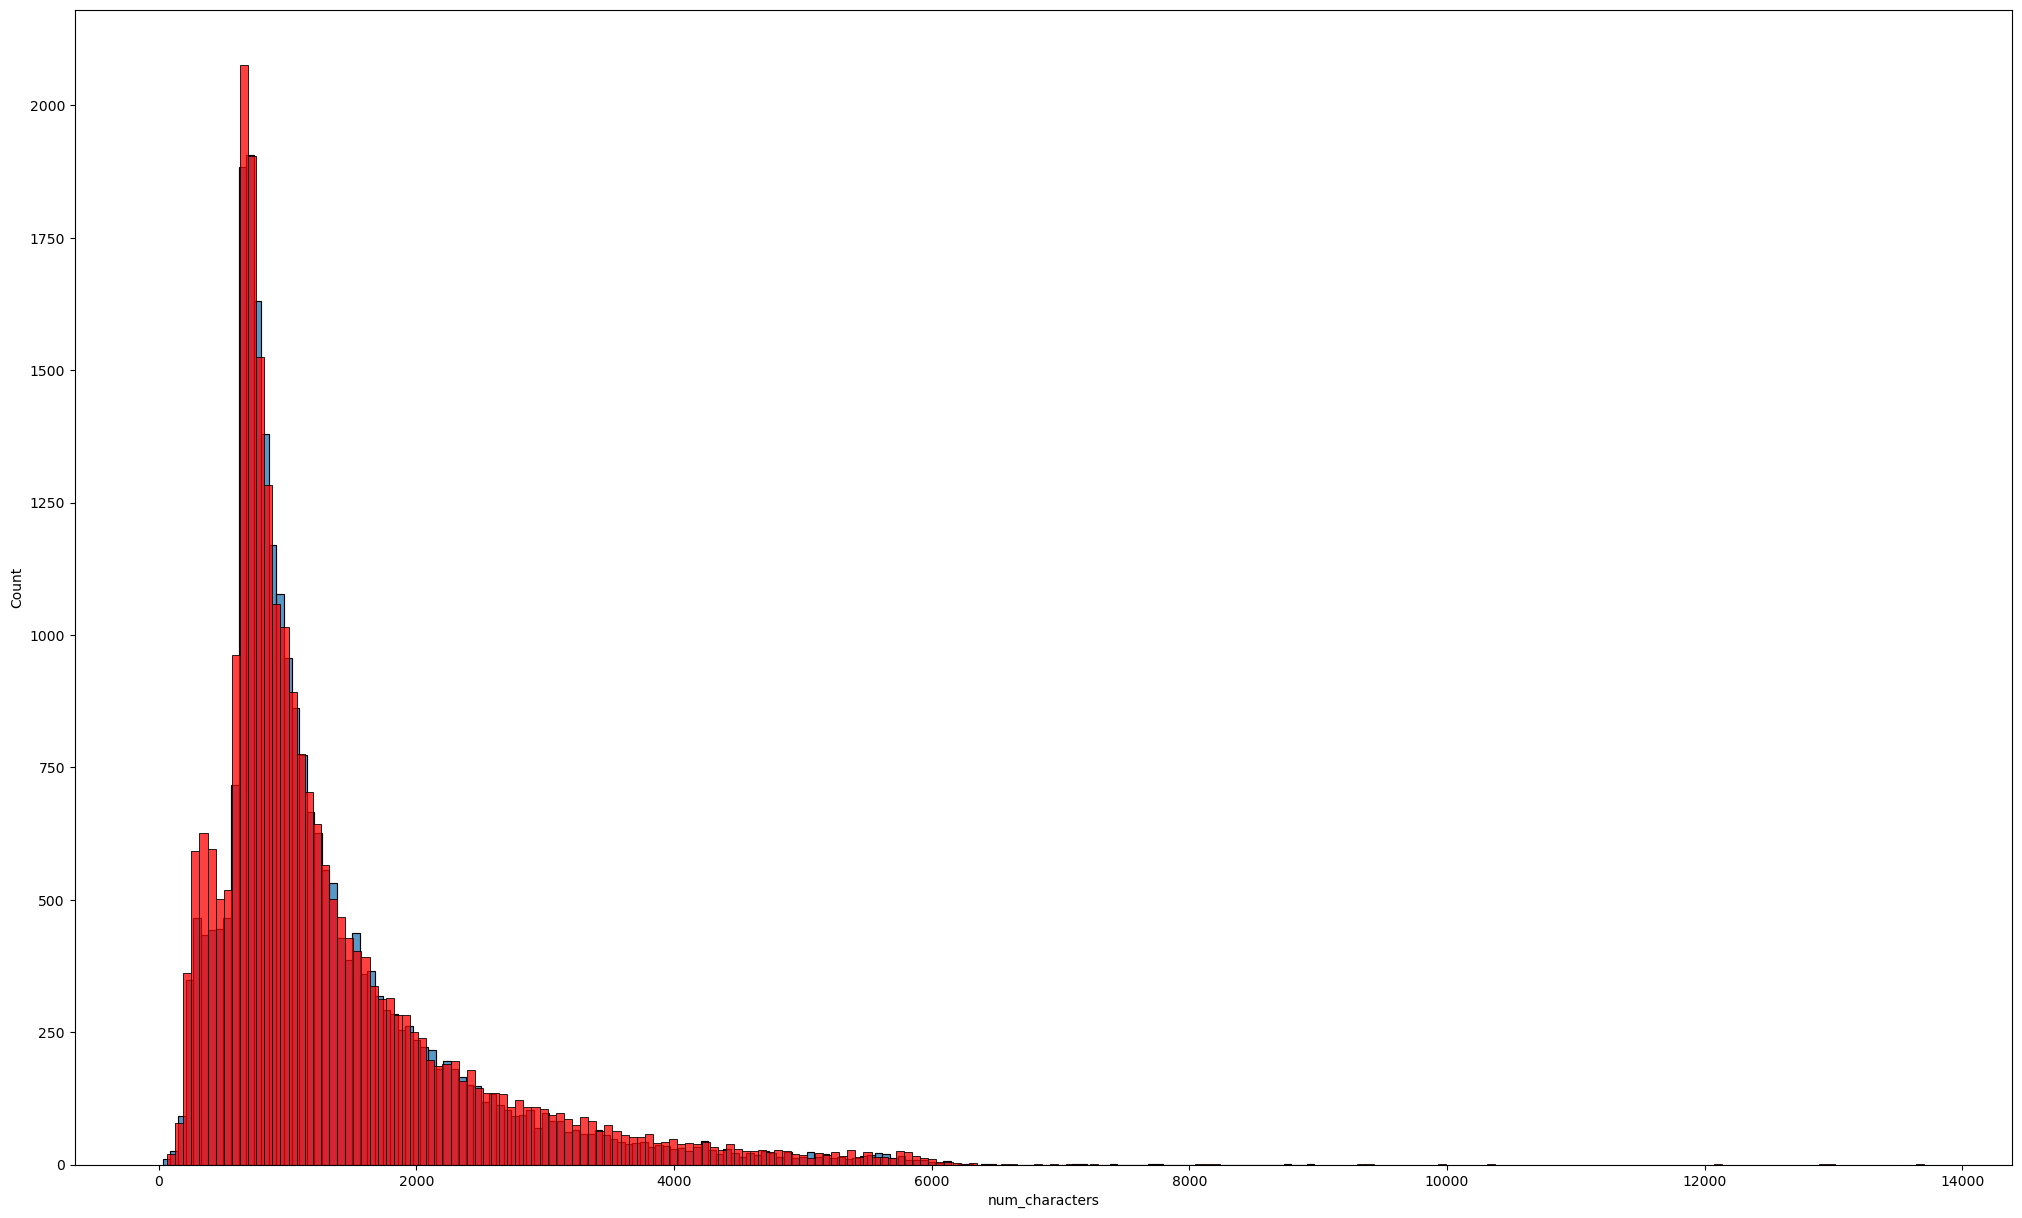

In [42]:
plt.figure(figsize=(25, 15))
sns.histplot(df[df['sentiment']==0]['num_characters'])
sns.histplot(df[df['sentiment']==1]['num_characters'], color = 'red')

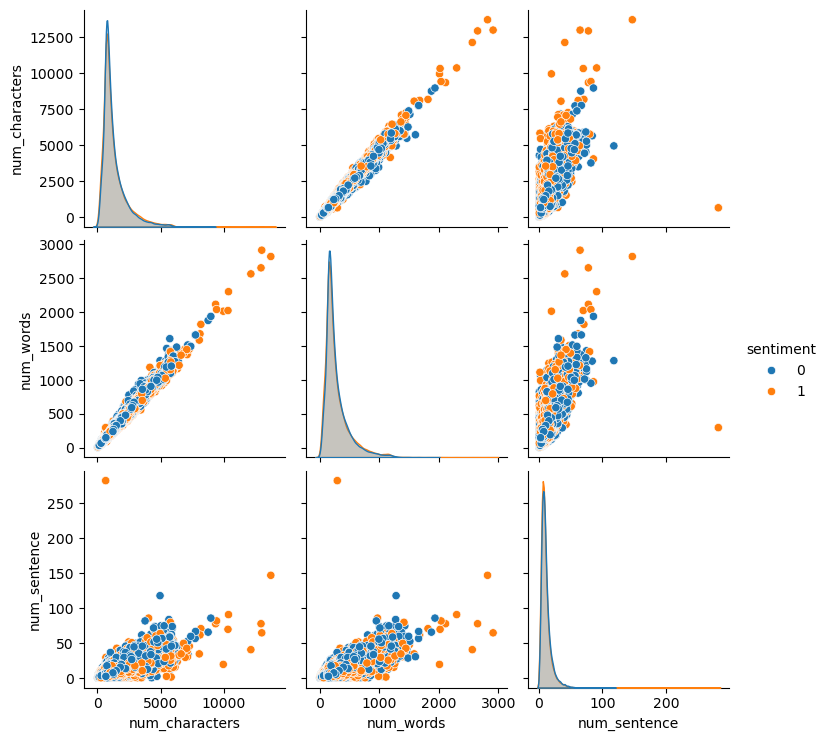

In [43]:
sns.pairplot(df,hue="sentiment")

<Axes: >

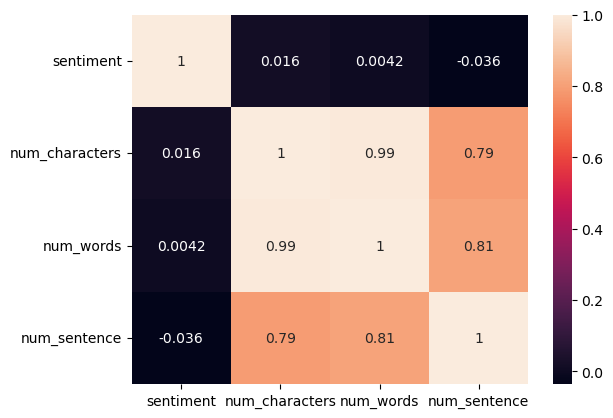

In [44]:
sns.heatmap(df[['sentiment','num_characters','num_words','num_sentence']].corr(), annot = True)

# Text Preprocessing 

In [46]:
import re
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

# Download required NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# Precompute stopwords and stemmer
ps = PorterStemmer()
STOP_WORDS = set(stopwords.words('english'))

def transform_text(text):
    # Stage 1: Lowercase
    text = text.lower()
    
    # Stage 2: Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    
    # Stage 3: Tokenize
    text = nltk.word_tokenize(text)
    
    # Stage 4: Remove non-alphanumeric tokens
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    # Stage 5: Remove stopwords and punctuation
    text = y[:]
    y.clear()
    for i in text:
        if i not in STOP_WORDS and i not in string.punctuation:
            y.append(i)
    
    # Stage 6: Stem each word
    text = y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    
    return " ".join(y)


# Usage
transformed = transform_text(df['review'][0])
print(transformed)

one review mention watch 1 oz episod hook right exactli happen first thing struck oz brutal unflinch scene violenc set right word go trust show faint heart timid show pull punch regard drug sex violenc hardcor classic use word call oz nicknam given oswald maximum secur state penitentari focus mainli emerald citi experiment section prison cell glass front face inward privaci high agenda em citi home mani aryan muslim gangsta latino christian italian irish scuffl death stare dodgi deal shadi agreement never far away would say main appeal show due fact goe show would dare forget pretti pictur paint mainstream audienc forget charm forget romanc oz mess around first episod ever saw struck nasti surreal could say readi watch develop tast oz got accustom high level graphic violenc violenc injustic crook guard sold nickel inmat kill order get away well manner middl class inmat turn prison bitch due lack street skill prison experi watch oz may becom comfort uncomfort view that get touch darker 

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\chira\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\chira\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\chira\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [47]:
df['review'] = df['review'].apply(transform_text)

In [48]:
df['review'].head()

0    one review mention watch 1 oz episod hook righ...
1    wonder littl product film techniqu fashion giv...
2    thought wonder way spend time hot summer weeke...
3    basic famili littl boy jake think zombi closet...
4    petter mattei love time money visual stun film...
Name: review, dtype: object

In [49]:
import wordcloud
from wordcloud import WordCloud

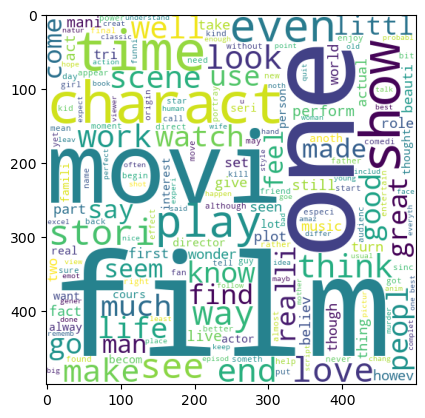

In [50]:
wc = WordCloud(width = 500, height = 500, min_font_size=10, background_color='white')
positive_wc = wc.generate(df[df['sentiment']==1]['review'].str.cat(sep=" "))
plt.imshow(positive_wc)

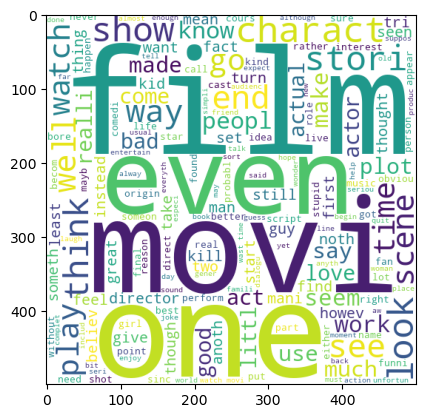

In [51]:
wc = WordCloud(width = 500, height = 500, min_font_size=10, background_color='white')
negative_wc = wc.generate(df[df['sentiment']==0]['review'].str.cat(sep=" "))
plt.imshow(negative_wc)

In [52]:
df['review']

0        one review mention watch 1 oz episod hook righ...
1        wonder littl product film techniqu fashion giv...
2        thought wonder way spend time hot summer weeke...
3        basic famili littl boy jake think zombi closet...
4        petter mattei love time money visual stun film...
                               ...                        
49995    thought movi right good job creativ origin fir...
49996    bad plot bad dialogu bad act idiot direct anno...
49997    cathol taught parochi elementari school nun ta...
49998    go disagre previou comment side maltin one sec...
49999    one expect star trek movi high art fan expect ...
Name: review, Length: 50000, dtype: object

In [53]:
# Text Vectorization 
# Using Bag of Words
df.head()

,review,sentiment,num_characters,num_words,num_sentence
0,one review mention watch 1 oz episod hook righ...,1,1761,380,10
1,wonder littl product film techniqu fashion giv...,1,998,201,7
2,thought wonder way spend time hot summer weeke...,1,926,205,4
3,basic famili littl boy jake think zombi closet...,0,748,175,6
4,petter mattei love time money visual stun film...,1,1317,283,9


In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer
# cv = CountVectorizer(max_features=20000)
tfidf = TfidfVectorizer(max_features=20000)

In [57]:
X = tfidf.fit_transform(df['review']).toarray()

In [58]:
X.shape

(50000, 20000)

In [59]:
y = df['sentiment'].values

In [60]:
from sklearn.model_selection import train_test_split

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [62]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [63]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [64]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))
print(precision_score(y_test, y_pred1))

0.6991
[[4170  791]
 [2218 2821]]
0.7810077519379846


In [65]:
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))
print(precision_score(y_test, y_pred2))

0.8579
[[4281  680]
 [ 741 4298]]
0.8633989554037766


In [66]:
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))
print(precision_score(y_test, y_pred3))

0.8467
[[4317  644]
 [ 889 4150]]
0.8656654151022111


In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

log_regression = LogisticRegression()
linear_svc = LinearSVC()

# Logistic Regression
log_regression.fit(X_train, y_train)
y_pred4 = log_regression.predict(X_test)
print(accuracy_score(y_test, y_pred4))
print(confusion_matrix(y_test, y_pred4))
print(precision_score(y_test, y_pred4))


0.89
[[4338  623]
 [ 477 4562]]
0.8798457087753134


In [68]:
# LinearSVC
linear_svc.fit(X_train, y_train)
y_pred5 = linear_svc.predict(X_test)
print(accuracy_score(y_test, y_pred5))
print(confusion_matrix(y_test, y_pred5))
print(precision_score(y_test, y_pred5))

0.8916
[[4360  601]
 [ 483 4556]]
0.8834593756059724


In [69]:
!pip install optuna

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
import optuna

def objective(trial):
    classifier_name = trial.suggest_categorical('classifier', ['LogisticRegression', 'LinearSVC', 'MultinomialNB'])
    
    if classifier_name == 'LogisticRegression':
        C = trial.suggest_float('C', 0.01, 100, log=True)
        solver = trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'saga'])
        max_iter = trial.suggest_int('max_iter', 100, 1000)
        penalty = 'l2'
        model = LogisticRegression(
            C=C,
            solver=solver,
            max_iter=max_iter,
            penalty=penalty,
            random_state=42
        )

    elif classifier_name == 'LinearSVC':
        C = trial.suggest_float('C', 0.01, 100, log=True)
        loss = trial.suggest_categorical('loss', ['hinge', 'squared_hinge'])
        max_iter = trial.suggest_int('max_iter', 500, 1000)
        model = LinearSVC(
            C=C,
            loss=loss,
            max_iter=max_iter,
            random_state=42          
        )

    elif classifier_name == 'MultinomialNB':
        alpha = trial.suggest_float('alpha', 0.01, 10.0, log=True)
        fit_prior = trial.suggest_categorical('fit_prior', [True, False])
        model = MultinomialNB(
            alpha=alpha,
            fit_prior=fit_prior      
        )

    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()
    return score


# Create a study object and optimize the objective function
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler()
)
study.optimize(objective, n_trials=50, timeout=120)

# Print best results
print("Best Accuracy: ", study.best_value)
print("Best Parameters:", study.best_params)

[I 2026-03-20 11:48:56,110] A new study created in memory with name: no-name-d265b3bc-5f49-446c-8a1d-fc96ef57c22f
[I 2026-03-20 11:50:41,656] Trial 0 finished with value: 0.8398500160494113 and parameters: {'classifier': 'LogisticRegression', 'C': 0.02031637475013227, 'solver': 'liblinear', 'max_iter': 534}. Best is trial 0 with value: 0.8398500160494113.
[I 2026-03-20 11:52:07,232] Trial 1 finished with value: 0.8629249667044885 and parameters: {'classifier': 'LogisticRegression', 'C': 0.0811648566426449, 'solver': 'liblinear', 'max_iter': 618}. Best is trial 1 with value: 0.8629249667044885.


Best Accuracy:  0.8629249667044885
Best Parameters: {'classifier': 'LogisticRegression', 'C': 0.0811648566426449, 'solver': 'liblinear', 'max_iter': 618}


In [86]:
import pickle
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(log_regression, open('model.pkl', 'wb'))